In [1]:
# STEP 1 — IMPORT LIBRARIES

import pandas as pd
import numpy as np

# Data splitting
from sklearn.model_selection import train_test_split

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# STEP 2 — MOUNT GOOGLE DRIVE

from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


# LOAD PREPROCESSED DATASET

file_path = '/content/drive/MyDrive/processed_fake_news_dataset.csv'

# Read dataset
df = pd.read_csv(file_path)
print("Dataset Loaded Successfully!")



print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
display(df.head())

Mounted at /content/drive
Dataset Loaded Successfully!

Dataset Shape:
(44685, 6)

Columns:
Index(['title', 'text', 'subject', 'label', 'content', 'processed_text'], dtype='object')

First 5 Rows:


,title,text,subject,label,content,processed_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein call circuit court committed coup ét...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,1,Trump drops Steve Bannon from National Securit...,trump drop steve bannon national security coun...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,1,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u lift jones act shipping ...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,0,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,1,Donald Trump heads for Scotland to reopen a go...,donald trump head scotland reopen golf resort ...


In [3]:
# STEP 3 — CREATE FEATURES AND LABELS

# Features (Input)
# We use processed textual data
# generated after NLP preprocessing

X = df["processed_text"]


# Labels (Target Output)
# 0 → Fake News
# 1 → Real News

y = df["label"]
print("Features and Labels Created Successfully!")




print("\nNumber of Articles:")
print(len(X))

print("\nLabel Distribution:")
print(y.value_counts())

Features and Labels Created Successfully!

Number of Articles:
44685

Label Distribution:
label
0    23477
1    21208
Name: count, dtype: int64


In [4]:
# STEP 4 — TF-IDF VECTORIZATION

# Create TF-IDF Vectorizer
#
# Purpose:
# Convert textual news data into
# numerical feature vectors.

tfidf = TfidfVectorizer(

    # Keep top 5000 important words
    max_features=5000,

    # Ignore extremely common words
    max_df=0.7,

    # Ignore very rare words
    min_df=2
)


# APPLY TF-IDF TRANSFORMATION
X_tfidf = tfidf.fit_transform(X)
print("TF-IDF Vectorization Completed!")



print("\nShape of TF-IDF Matrix:")
print(X_tfidf.shape)

TF-IDF Vectorization Completed!

Shape of TF-IDF Matrix:
(44685, 5000)


In [5]:
# STEP 5 — TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(

    X_tfidf,
    y,

    # 20% testing data
    test_size=0.2,

    # Reproducibility
    random_state=42,

    # Maintain label balance
    stratify=y
)
print("Train-Test Split Completed!")



print("\nTraining Feature Shape:")
print(X_train.shape)

print("\nTesting Feature Shape:")
print(X_test.shape)

print("\nTraining Labels Shape:")
print(y_train.shape)

print("\nTesting Labels Shape:")
print(y_test.shape)

Train-Test Split Completed!

Training Feature Shape:
(35748, 5000)

Testing Feature Shape:
(8937, 5000)

Training Labels Shape:
(35748,)

Testing Labels Shape:
(8937,)


In [6]:
# STEP 6 — TRAIN RANDOM FOREST MODEL

# Create Random Forest model
#
# Role in project:
# Random Forest classifies
# fake and real news using
# multiple decision trees.

rf_model = RandomForestClassifier(

    # Number of trees
    n_estimators=100,

    # Reproducibility
    random_state=42,

    # Use all CPU cores
    n_jobs=-1
)


print("Training Random Forest Model...")


# Train model
rf_model.fit(

    X_train,

    y_train
)


print("Random Forest Model Training Completed!")

Training Random Forest Model...
Random Forest Model Training Completed!


In [7]:
# STEP 7 — MAKE PREDICTIONS

# Predict labels for test dataset

y_pred_rf = rf_model.predict(

    X_test
)

print("Predictions Completed!")




print("\nFirst 10 Predictions:")

print(y_pred_rf[:10])

Predictions Completed!

First 10 Predictions:
[1 1 1 0 1 0 0 0 0 1]


In [8]:
# STEP 8 — RANDOM FOREST PERFORMANCE

# Calculate evaluation metrics

accuracy = accuracy_score(

    y_test,
    y_pred_rf
)

precision = precision_score(

    y_test,
    y_pred_rf
)

recall = recall_score(

    y_test,
    y_pred_rf
)

f1 = f1_score(

    y_test,
    y_pred_rf
)



# DISPLAY RESULTS

print("=" * 50)

print("RANDOM FOREST PERFORMANCE")

print("=" * 50)

print(f"\nAccuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1-Score  : {f1:.4f}")

RANDOM FOREST PERFORMANCE

Accuracy  : 0.9997
Precision : 0.9993
Recall    : 1.0000
F1-Score  : 0.9996


In [9]:
# STEP 9 — OVERFITTING CHECK

# Training accuracy
train_accuracy = rf_model.score(

    X_train,
    y_train
)


# Testing accuracy
test_accuracy = rf_model.score(

    X_test,
    y_test
)


print("=" * 50)

print("OVERFITTING CHECK")

print("=" * 50)

print(f"\nTraining Accuracy : {train_accuracy:.4f}")

print(f"Testing Accuracy  : {test_accuracy:.4f}")


# Difference
difference = train_accuracy - test_accuracy


print(f"\nDifference : {difference:.4f}")

OVERFITTING CHECK

Training Accuracy : 1.0000
Testing Accuracy  : 0.9997

Difference : 0.0003


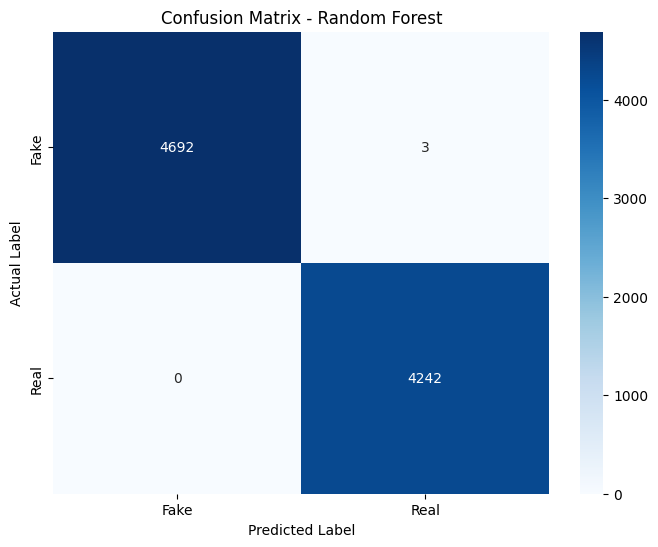

In [10]:
# STEP 10 — CONFUSION MATRIX

cm = confusion_matrix(

    y_test,
    y_pred_rf
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=["Fake", "Real"],

    yticklabels=["Fake", "Real"]
)

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.show()

In [11]:
# STEP 11 — CLASSIFICATION REPORT

print("=" * 60)

print("CLASSIFICATION REPORT")

print("=" * 60)


print(

    classification_report(

        y_test,

        y_pred_rf,

        target_names=[

            "Fake News",

            "Real News"
        ]
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Fake News       1.00      1.00      1.00      4695
   Real News       1.00      1.00      1.00      4242

    accuracy                           1.00      8937
   macro avg       1.00      1.00      1.00      8937
weighted avg       1.00      1.00      1.00      8937



### 1. True Negative (TN) = 4692

These are **fake news articles correctly classified as fake**.

This indicates that the model successfully detected a very large number of fake news articles with high accuracy.

---

### 2. False Positive (FP) = 3

These are **fake news articles incorrectly classified as real news**.

Only **3 fake articles escaped detection**, indicating an extremely low classification error.

A lower false positive value is preferred because undetected fake news reduces system reliability.

---

### 3. False Negative (FN) = 0

These are **real news articles incorrectly classified as fake news**.

The model did not misclassify any real news article as fake.

This indicates exceptionally strong real-news detection performance.

---

### 4. True Positive (TP) = 4242

These are **real news articles correctly classified as real**.

The model successfully identified all real news articles in the testing dataset.

---

## Overall Observation

The confusion matrix shows that the Random Forest model achieved extremely strong classification performance.

Out of **8937 test articles**, only **3 articles were misclassified**, resulting in **99.97% accuracy**.

This suggests that the model effectively learned the distinguishing patterns between fake and real news articles within the dataset.

In [12]:
# STEP 12 — CREATE RANDOM FOREST PIPELINE

# Import required libraries

from sklearn.pipeline import Pipeline

# CREATE PIPELINE

# Flow:
# Processed Text
#        ↓
# TF-IDF Vectorization
#        ↓
# Random Forest Prediction

rf_pipeline = Pipeline([

    (
        "tfidf",

        TfidfVectorizer(

            # Keep top important words
            max_features=5000,

            # Ignore extremely common words
            max_df=0.7,

            # Ignore very rare words
            min_df=2
        )
    ),

    (
        "random_forest",

        RandomForestClassifier(

            # Number of trees
            n_estimators=100,

            # Reproducibility
            random_state=42,

            # Faster training
            n_jobs=-1
        )
    )
])


print("Random Forest Pipeline Created Successfully!")

Random Forest Pipeline Created Successfully!


In [13]:
# STEP 13 — TRAIN TEST SPLIT (RAW TEXT)

# Raw processed text
X_raw = df["processed_text"]

# Labels
y = df["label"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(

    X_raw,
    y,

    # 20% testing data
    test_size=0.2,

    # Reproducibility
    random_state=42,

    # Maintain class balance
    stratify=y
)


print("Raw Text Train-Test Split Completed!")

print("\nTraining Data Shape:")
print(X_train_raw.shape)

print("\nTesting Data Shape:")
print(X_test_raw.shape)

Raw Text Train-Test Split Completed!

Training Data Shape:
(35748,)

Testing Data Shape:
(8937,)


In [14]:
# STEP 14 — TRAIN RANDOM FOREST PIPELINE

print("Training Random Forest Pipeline...")


# Train pipeline

rf_pipeline.fit(

    X_train_raw,

    y_train
)


print("Pipeline Training Completed Successfully!")

Training Random Forest Pipeline...
Pipeline Training Completed Successfully!


In [15]:
# STEP 15 — VALIDATE PIPELINE

# Make predictions

pipeline_predictions = rf_pipeline.predict(

    X_test_raw
)


# Calculate accuracy

pipeline_accuracy = accuracy_score(

    y_test,

    pipeline_predictions
)


print("Pipeline Accuracy:")

print(f"{pipeline_accuracy:.4f}")

Pipeline Accuracy:
0.9994


In [16]:
# STEP 16 — SAVE RANDOM FOREST PIPELINE
import joblib

# SAVE MODEL
joblib.dump(

    rf_pipeline,

    "random_forest_model.pkl"
)

print("Random Forest Pipeline Saved Successfully!")





from google.colab import files
files.download(

    "random_forest_model.pkl"
)

Random Forest Pipeline Saved Successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>